In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn tabpfn

Note: you may need to restart the kernel to use updated packages.


In [3]:
#loading dataset
import pandas as pd
df = pd.read_csv('data.csv')
df.head()

,ROWID,Country,State lgd code,State,District lgd code,District,YearCode,Year,CalendarDayCode,Calendar Day,...,Percentage of daily departure,Weekly actual,Weekly normal,Percentage of weekly departure,Cumulative actual,Cumulative normal,Percentage of cumulative departure,Monthly acutual,Monthly normal,Percentage of monthly departure
0,1,India,1,Jammu And Kashmir,1,Anantnag,2021,"Calendar Year (Jan - Dec), 2021",20210101,01-01-2021,...,-100.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.2,-100.0
1,2,India,1,Jammu And Kashmir,1,Anantnag,2021,"Calendar Year (Jan - Dec), 2021",20210102,02-01-2021,...,-100.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.2,-100.0
2,3,India,1,Jammu And Kashmir,1,Anantnag,2021,"Calendar Year (Jan - Dec), 2021",20210103,03-01-2021,...,519.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0,3.5,130.0
3,4,India,1,Jammu And Kashmir,1,Anantnag,2021,"Calendar Year (Jan - Dec), 2021",20210105,05-01-2021,...,897.0,NaN,NaN,NaN,NaN,NaN,NaN,40.7,5.6,626.0
4,5,India,1,Jammu And Kashmir,1,Anantnag,2021,"Calendar Year (Jan - Dec), 2021",20210106,06-01-2021,...,1707.0,NaN,NaN,NaN,NaN,NaN,NaN,66.0,7.0,842.0


In [5]:
#checking details
print(df.info())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 961752 entries, 0 to 961751
Data columns (total 30 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   ROWID                               961752 non-null  int64  
 1   Country                             961752 non-null  object 
 2   State lgd code                      961752 non-null  int64  
 3   State                               961752 non-null  object 
 4   District lgd code                   961752 non-null  int64  
 5   District                            961752 non-null  object 
 6   YearCode                            961752 non-null  int64  
 7   Year                                961752 non-null  object 
 8   CalendarDayCode                     961752 non-null  int64  
 9   Calendar Day                        961752 non-null  object 
 10  Obj_id                              36238 non-null   float64
 11  Daily category            

ROWID                                      0
Country                                    0
State lgd code                             0
State                                      0
District lgd code                          0
District                                   0
YearCode                                   0
Year                                       0
CalendarDayCode                            0
Calendar Day                               0
Obj_id                                925514
Daily category                             0
Weekly date                           925638
Weekly category                       925514
Cumulative date                       925514
Cumulative category                   925514
Monthly date                               0
Monthly category                           0
Daily actual                          107947
Daily normal                           98750
Percentage of daily departure         109130
Weekly actual                         930147
Weekly nor

In [7]:
#extracting relevant data
import numpy as np

df_daily = df[['Calendar Day', 'State', 'District', 'Daily actual', 'Daily normal', 'Percentage of daily departure']].copy()
df_daily = df_daily.dropna(subset=['Daily actual', 'Daily normal'])
df_daily['Calendar Day'] = pd.to_datetime(df_daily['Calendar Day'], errors='coerce')
df_daily['Month'] = df_daily['Calendar Day'].dt.month
df_daily['Year'] = df_daily['Calendar Day'].dt.year


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

In [11]:
#downloading TABpfn
!pip install tabpfn
from tabpfn import TabPFNRegressor

In [13]:
#selecting relevant columns
df_daily['simulated_forecast'] = df_daily['Daily normal']
df_daily['forecast_error'] = df_daily['Daily actual'] - df_daily['simulated_forecast']

In [15]:
#converting date and extract features
df_daily['Calendar Day'] = pd.to_datetime(df_daily['Calendar Day'], errors='coerce')
df_daily = df_daily.dropna(subset=['Calendar Day'])
df_daily['Month'] = df_daily['Calendar Day'].dt.month
df_daily['Year'] = df_daily['Calendar Day'].dt.year

In [17]:
#simulating forecast and error
df_daily['simulated_forecast'] = df_daily['Daily normal']
df_daily['forecast_error'] = df_daily['Daily actual'] - df_daily['simulated_forecast']

In [19]:
#encoding categorical variables
le_state = LabelEncoder()
le_district = LabelEncoder()
df_daily['State_enc'] = le_state.fit_transform(df_daily['State'])
df_daily['District_enc'] = le_district.fit_transform(df_daily['District'])

In [21]:
#preparing features and target
features = ['simulated_forecast', 'Month', 'Year', 'State_enc', 'District_enc','Daily normal']
X = df_daily[features]
y = df_daily['forecast_error']

In [23]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
#reduce the size of data
X_train_small = X_train.sample(n=1000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

In [27]:
#train TabPFN
regressor = TabPFNRegressor(device="cpu")
regressor.fit(X_train_small.to_numpy(), y_train_small.to_numpy())

C:\Users\aarus\anaconda3\Lib\site-packages\tabpfn\regressor.py:459: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(self.device, X)


TabPFNRegressor(device='cpu')

In [29]:
#predicting on a small test subset
X_test_small = X_test.sample(n=500, random_state=42)
y_test_small = y_test.loc[X_test_small.index]

In [31]:
#predictions
preds = regressor.predict(X_test_small.to_numpy())

In [33]:
#evaluation
mae = mean_absolute_error(y_test_small, preds)
print(f"MAE of forecast error correction (1000 sample train, 500 test): {mae:.2f} mm")

MAE of forecast error correction (1000 sample train, 500 test): 3.71 mm


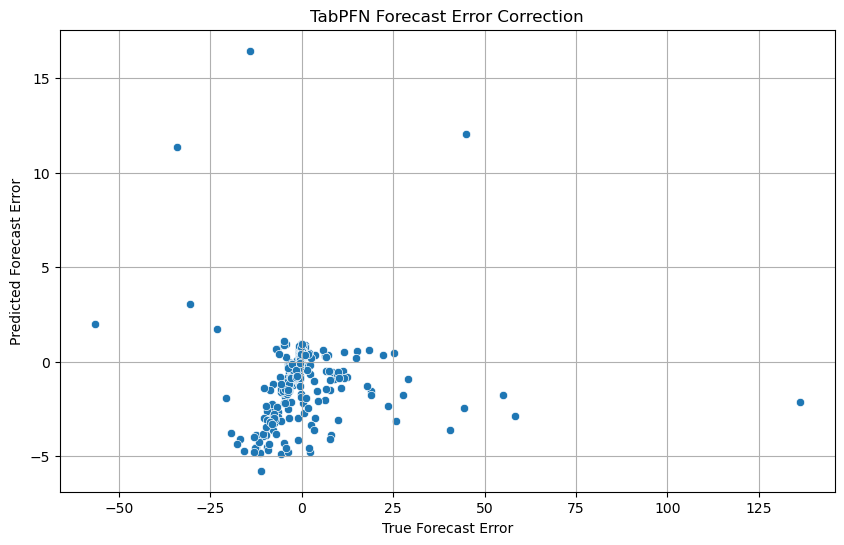

In [35]:
#visualizing predictions
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test_small, y=preds)
plt.xlabel("True Forecast Error")
plt.ylabel("Predicted Forecast Error")
plt.title("TabPFN Forecast Error Correction")
plt.grid(True)
plt.show()

In [37]:
#adjusting simulated forecast
adjusted_forecast = X_test_small['simulated_forecast'] + preds
actual = X_test_small.copy()
actual['adjusted_forecast'] = adjusted_forecast
actual['true_actual'] = y_test_small + X_test_small['simulated_forecast']

In [39]:
#evaluating adjusted forecast
adjusted_mae = mean_absolute_error(actual['true_actual'], actual['adjusted_forecast'])
print(f"MAE of adjusted forecast: {adjusted_mae:.2f} mm")

MAE of adjusted forecast: 3.71 mm


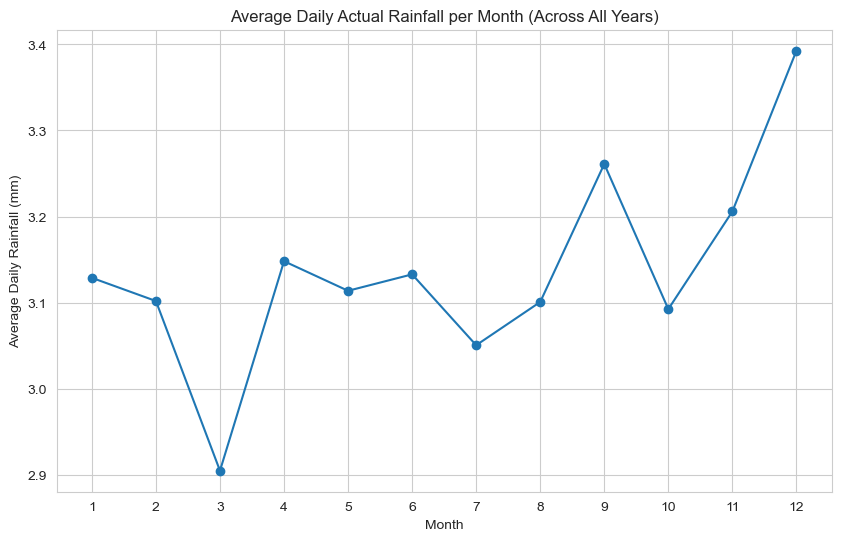

In [107]:
# plotting monthly average actual rainfall
df_daily.groupby('Month')['Daily actual'].mean().plot(kind='line', marker='o', title='Average Daily Actual Rainfall per Month (Across All Years)')
plt.xlabel("Month")
plt.ylabel("Average Daily Rainfall (mm)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

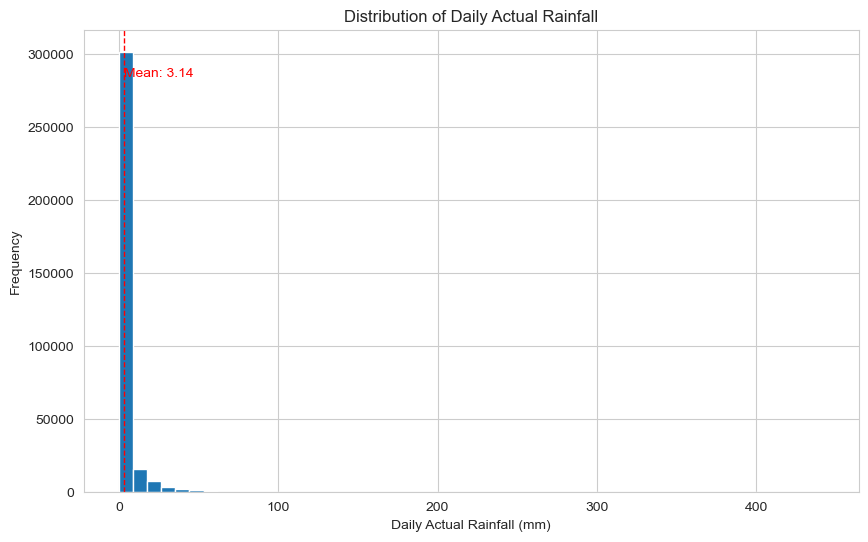

In [75]:
#distribution of daily actual rainfall
df_daily['Daily actual'].plot(kind='hist', bins=50, title='Distribution of Daily Actual Rainfall')
plt.xlabel("Daily Actual Rainfall (mm)")
plt.ylabel("Frequency")
plt.axvline(df_daily['Daily actual'].mean(), color='red', linestyle='dashed', linewidth=1)
plt.text(df_daily['Daily actual'].mean()*1.1, plt.ylim()[1]*0.9, f'Mean: {df_daily["Daily actual"].mean():.2f}', color = 'red')
plt.show()

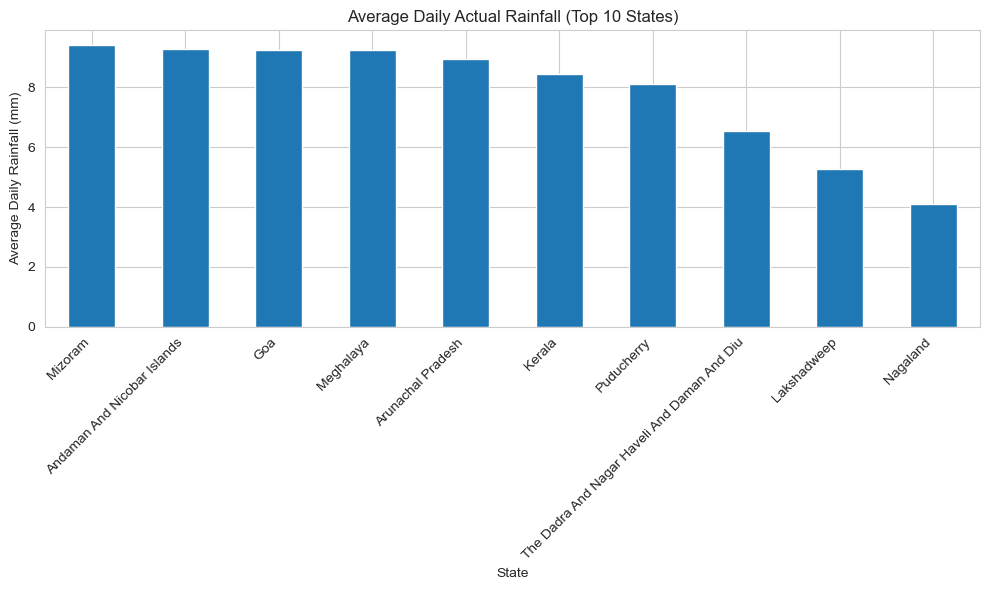

In [77]:
#comparing average rainfall across categories (e.g., States)
avg_rainfall_state = df_daily.groupby('State')['Daily actual'].mean().sort_values(ascending=False)
avg_rainfall_state.head(10).plot(kind='bar', title='Average Daily Actual Rainfall (Top 10 States)')
plt.xlabel("State")
plt.ylabel("Average Daily Rainfall (mm)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout() 
plt.show()

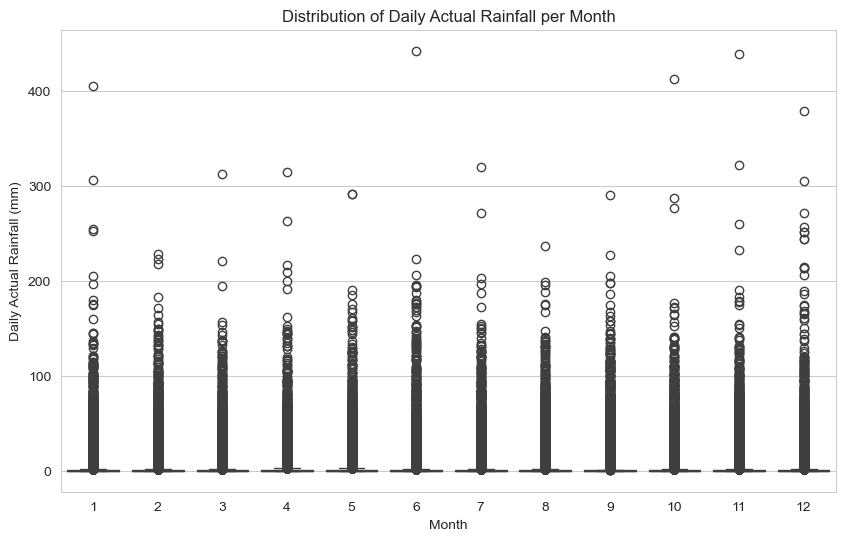

In [79]:
# distribution summary across categories
sns.boxplot(data=df_daily, x='Month', y='Daily actual')
plt.title('Distribution of Daily Actual Rainfall per Month')
plt.xlabel("Month")
plt.ylabel("Daily Actual Rainfall (mm)")
plt.show()

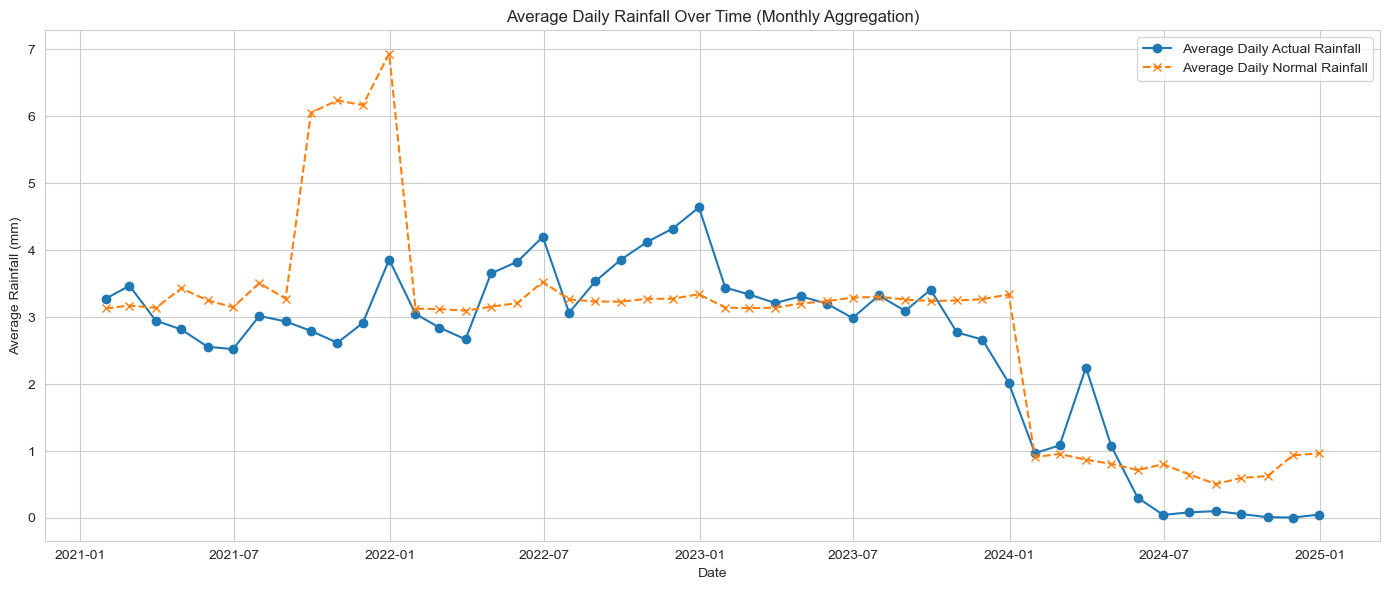

In [113]:
#time series plot of average rainfall (actual vs. normal)
df_daily['Calendar Day'] = pd.to_datetime(df_daily['Calendar Day'])
df_analysis = df_daily.set_index('Calendar Day')
monthly_avg = df_analysis[['Daily actual', 'Daily normal']].resample('ME').mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_avg.index, monthly_avg['Daily actual'], label='Average Daily Actual Rainfall', marker='o', linestyle='-')
plt.plot(monthly_avg.index, monthly_avg['Daily normal'], label='Average Daily Normal Rainfall', marker='x', linestyle='--')

plt.title('Average Daily Rainfall Over Time (Monthly Aggregation)')
plt.xlabel('Date')
plt.ylabel('Average Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

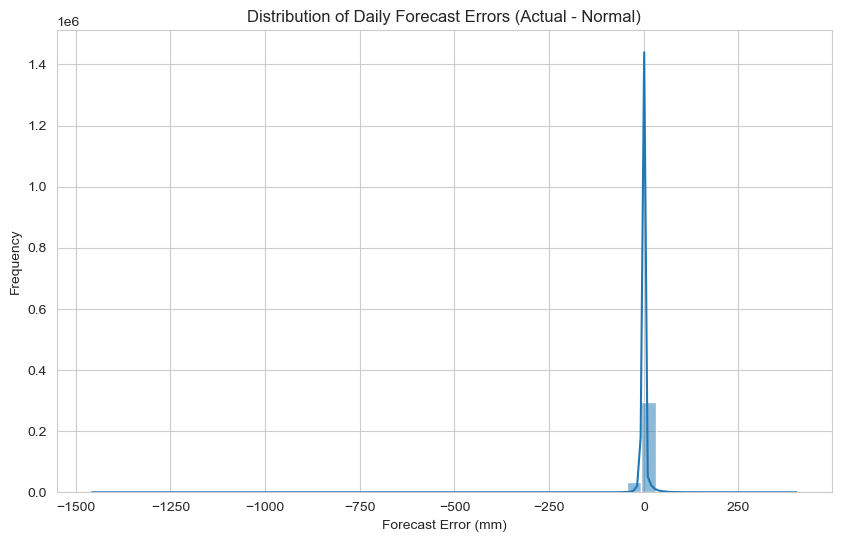

In [117]:
#distribution of forecast errors
plt.figure(figsize=(10, 6))
sns.histplot(df_daily['forecast_error'], kde=True, bins=50) # Use the error calculated earlier
plt.title('Distribution of Daily Forecast Errors (Actual - Normal)')
plt.xlabel('Forecast Error (mm)')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.show()

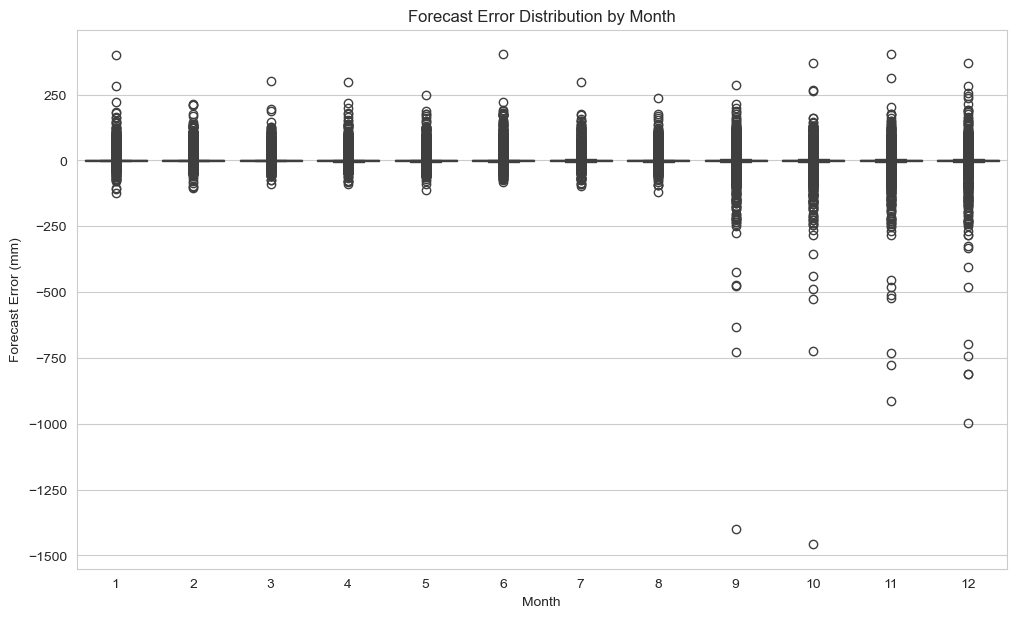

In [123]:
#forecast errors by month(helps recognize seasonal patterns)
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_daily, x='Month', y='forecast_error')
plt.title('Forecast Error Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Forecast Error (mm)')
plt.grid(True, axis='y')
plt.show()

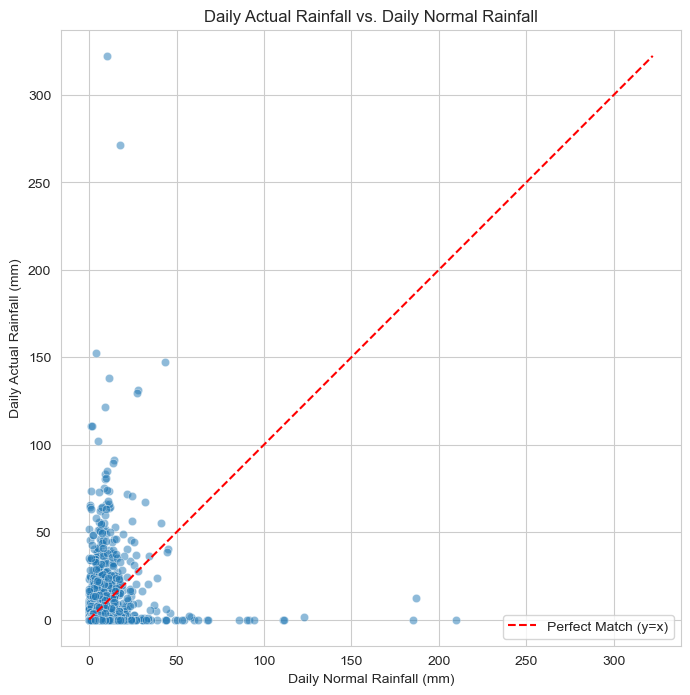

In [119]:
#actual vs. normal rainfall
plt.figure(figsize=(8, 8))
sample_df = df_daily.sample(n=min(5000, len(df_daily)), random_state=42)
sns.scatterplot(data=sample_df, x='Daily normal', y='Daily actual', alpha=0.5)
plt.plot([0, sample_df[['Daily normal', 'Daily actual']].max().max()], # Add y=x line
         [0, sample_df[['Daily normal', 'Daily actual']].max().max()],
         color='red', linestyle='--', label='Perfect Match (y=x)')
plt.title('Daily Actual Rainfall vs. Daily Normal Rainfall')
plt.xlabel('Daily Normal Rainfall (mm)')
plt.ylabel('Daily Actual Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

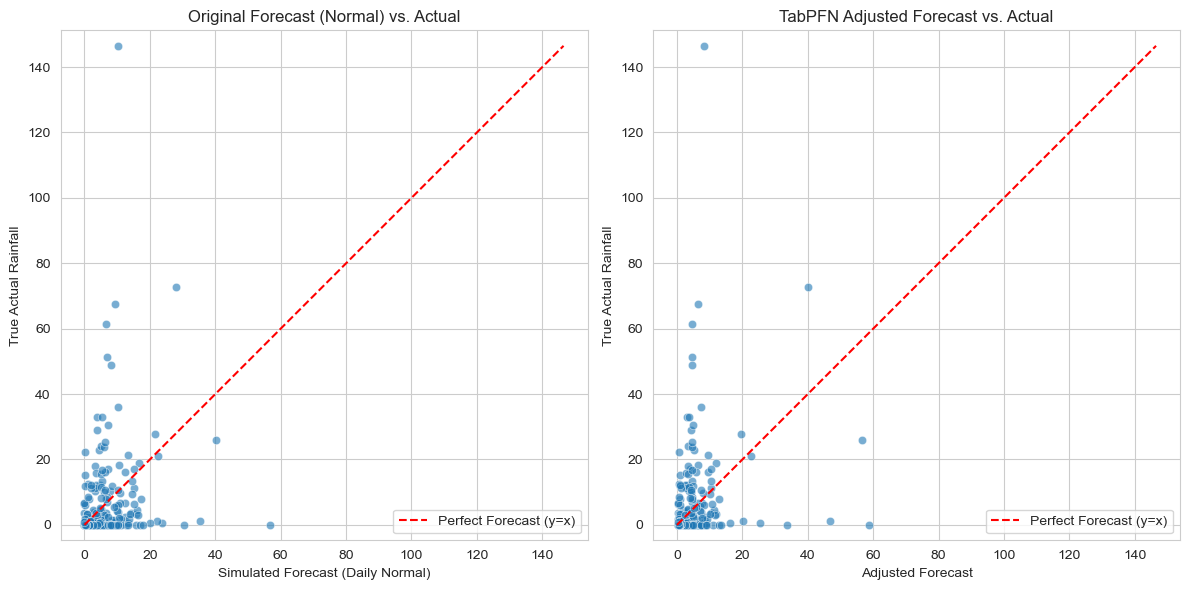

MAE of original forecast (Daily Normal vs Actual) on test set: 3.86 mm
MAE of adjusted forecast (TabPFN vs Actual) on test set: 3.71 mm


In [121]:
#5.model improvement visualization (using test set results)
plt.figure(figsize=(12, 6))

# Plot 1: original forecast vs true actual
plt.subplot(1, 2, 1)
sns.scatterplot(x=actual['simulated_forecast'], y=actual['true_actual'], alpha=0.6)
max_val = max(actual['simulated_forecast'].max(), actual['true_actual'].max())
min_val = min(actual['simulated_forecast'].min(), actual['true_actual'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast (y=x)')
plt.title('Original Forecast (Normal) vs. Actual')
plt.xlabel('Simulated Forecast (Daily Normal)')
plt.ylabel('True Actual Rainfall')
plt.grid(True)
plt.axis('equal')
plt.legend()

# Plot 2: adjusted forecast vs true actual
plt.subplot(1, 2, 2)
sns.scatterplot(x=actual['adjusted_forecast'], y=actual['true_actual'], alpha=0.6)
max_val = max(actual['adjusted_forecast'].max(), actual['true_actual'].max())
min_val = min(actual['adjusted_forecast'].min(), actual['true_actual'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Forecast (y=x)')
plt.title('TabPFN Adjusted Forecast vs. Actual')
plt.xlabel('Adjusted Forecast')
plt.ylabel('True Actual Rainfall')
plt.grid(True)
plt.axis('equal')
plt.legend()

plt.tight_layout()
plt.show()

print(f"MAE of original forecast (Daily Normal vs Actual) on test set: {mean_absolute_error(actual['true_actual'], actual['simulated_forecast']):.2f} mm")
print(f"MAE of adjusted forecast (TabPFN vs Actual) on test set: {adjusted_mae:.2f} mm") # From your code